In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier, Pool
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

/Users/aaryan/Desktop/ML_Project_2/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load and Explore Data

In [2]:
# Load original datasets
train_df = pd.read_csv('../dataset/train.csv')
test_df = pd.read_csv('../dataset/test.csv')

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print(f"\nTarget distribution:")
print(train_df['retention_status'].value_counts())
print(f"\nClass balance: {train_df['retention_status'].value_counts(normalize=True)}")

# Check missing values
print("\n" + "="*60)
print("Missing Values Analysis")
print("="*60)
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
for col in missing.index:
    pct = (missing[col] / len(train_df)) * 100
    print(f"{col}: {missing[col]} ({pct:.2f}%)")

Training data shape: (59611, 24)
Test data shape: (14900, 23)

Target distribution:
retention_status
Stayed    31265
Left      28346
Name: count, dtype: int64

Class balance: retention_status
Stayed    0.524484
Left      0.475516
Name: proportion, dtype: float64

Missing Values Analysis
work_life_balance_rating: 10144 (17.02%)
venture_satisfaction: 7164 (12.02%)
num_dependents: 4780 (8.02%)
years_since_founding: 4184 (7.02%)
team_size_category: 2992 (5.02%)
monthly_revenue_generated: 1800 (3.02%)


## 2. Advanced Data Preprocessing & Feature Engineering

Strategy:
1. **Intelligent Missing Value Handling**: Use mode for categorical, median for numerical, with domain knowledge
2. **Feature Engineering**: Create 40+ interaction and transformation features
3. **CatBoost Native Categorical Handling**: Keep categorical variables as strings
4. **Ordinal Encoding**: Encode ordinal features with proper ordering

In [3]:
def preprocess_and_engineer_features(df, is_train=True):
    """
    Advanced preprocessing and feature engineering optimized for CatBoost.
    Focuses on maximizing predictive power while handling missing values intelligently.
    """
    df = df.copy()
    
    # Save founder_id for later
    founder_ids = df['founder_id'].copy()
    df = df.drop('founder_id', axis=1)
    
    # Separate target if training data
    if is_train and 'retention_status' in df.columns:
        target = df['retention_status'].copy()
        df = df.drop('retention_status', axis=1)
    else:
        target = None
    
    # ==================== Missing Value Imputation ====================
    
    # Numerical features: use median
    if df['monthly_revenue_generated'].isnull().any():
        df['monthly_revenue_generated'].fillna(df['monthly_revenue_generated'].median(), inplace=True)
    
    if df['num_dependents'].isnull().any():
        df['num_dependents'].fillna(0, inplace=True)  # Assume 0 dependents if missing
    
    if df['years_since_founding'].isnull().any():
        df['years_since_founding'].fillna(df['years_since_founding'].median(), inplace=True)
    
    # Categorical features: use mode or domain-specific defaults
    if df['work_life_balance_rating'].isnull().any():
        df['work_life_balance_rating'].fillna('Fair', inplace=True)  # Neutral default
    
    if df['venture_satisfaction'].isnull().any():
        df['venture_satisfaction'].fillna('Medium', inplace=True)  # Neutral default
    
    if df['team_size_category'].isnull().any():
        df['team_size_category'].fillna(df['team_size_category'].mode()[0], inplace=True)
    
    # ==================== Ordinal Encoding for Ordinal Features ====================
    
    # Education level (ordinal)
    education_order = {
        'High School': 1,
        'Associate Degree': 2,
        "Bachelor's Degree": 3,
        "Master's Degree": 4,
        'PhD': 5
    }
    df['education_level_encoded'] = df['education_background'].map(education_order)
    
    # Work-life balance (ordinal)
    balance_order = {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4}
    df['balance_score'] = df['work_life_balance_rating'].map(balance_order)
    
    # Satisfaction (ordinal)
    satisfaction_order = {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}
    df['satisfaction_score'] = df['venture_satisfaction'].map(satisfaction_order)
    
    # Performance (ordinal)
    performance_order = {'Low': 1, 'Below Average': 2, 'Average': 3, 'High': 4}
    df['performance_score'] = df['startup_performance_rating'].map(performance_order)
    
    # Reputation (ordinal)
    reputation_order = {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4}
    df['reputation_score'] = df['startup_reputation'].map(reputation_order)
    
    # Visibility (ordinal)
    visibility_order = {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}
    df['visibility_score'] = df['founder_visibility'].map(visibility_order)
    
    # ==================== Feature Engineering ====================
    
    # 1. Revenue-based features
    df['revenue_per_year'] = df['monthly_revenue_generated'] / (df['years_with_startup'] + 1)
    df['log_revenue'] = np.log1p(df['monthly_revenue_generated'])
    df['revenue_per_founding_year'] = df['monthly_revenue_generated'] / (df['years_since_founding'] + 1)
    df['is_high_revenue'] = (df['monthly_revenue_generated'] > df['monthly_revenue_generated'].quantile(0.75)).astype(int)
    df['is_low_revenue'] = (df['monthly_revenue_generated'] < df['monthly_revenue_generated'].quantile(0.25)).astype(int)
    
    # 2. Age-related features
    df['age_when_joined'] = df['founder_age'] - df['years_with_startup']
    df['is_young_founder'] = (df['founder_age'] < 30).astype(int)
    df['is_senior_founder'] = (df['founder_age'] > 50).astype(int)
    df['is_prime_age'] = ((df['founder_age'] >= 30) & (df['founder_age'] <= 45)).astype(int)
    df['age_squared'] = df['founder_age'] ** 2  # Non-linear age effect
    
    # 3. Experience and tenure features
    df['experience_ratio'] = df['years_with_startup'] / (df['founder_age'] + 1)
    df['is_new_founder'] = (df['years_with_startup'] <= 2).astype(int)
    df['is_veteran_founder'] = (df['years_with_startup'] >= 10).astype(int)
    df['tenure_revenue_ratio'] = (df['years_with_startup'] + 1) / (df['monthly_revenue_generated'] + 1)
    df['years_to_founding_ratio'] = df['years_with_startup'] / (df['years_since_founding'] + 1)
    
    # 4. Work-life balance composites
    df['works_overtime'] = (df['working_overtime'] == 'Yes').astype(int)
    df['overtime_with_poor_balance'] = ((df['working_overtime'] == 'Yes') & 
                                         (df['work_life_balance_rating'].isin(['Poor', 'Fair']))).astype(int)
    df['good_balance_no_overtime'] = ((df['working_overtime'] == 'No') & 
                                       (df['work_life_balance_rating'].isin(['Good', 'Excellent']))).astype(int)
    df['balance_overtime_score'] = df['balance_score'] * (2 - df['works_overtime'])  # Penalize overtime
    
    # 5. Performance and satisfaction composites
    df['engagement_score'] = (df['satisfaction_score'] + df['performance_score'] + df['balance_score']) / 3
    df['high_performer_satisfied'] = ((df['performance_score'] >= 3) & 
                                       (df['satisfaction_score'] >= 3)).astype(int)
    df['low_performer_unsatisfied'] = ((df['performance_score'] <= 2) & 
                                        (df['satisfaction_score'] <= 2)).astype(int)
    df['performance_satisfaction_gap'] = df['performance_score'] - df['satisfaction_score']
    df['satisfaction_performance_product'] = df['satisfaction_score'] * df['performance_score']
    
    # 6. Leadership and funding features
    df['has_led_funding'] = (df['funding_rounds_led'] > 0).astype(int)
    df['has_multiple_funding'] = (df['funding_rounds_led'] > 1).astype(int)
    df['funding_experience_score'] = df['funding_rounds_led'] * df['years_with_startup']
    df['avg_funding_per_year'] = df['funding_rounds_led'] / (df['years_with_startup'] + 1)
    df['funding_squared'] = df['funding_rounds_led'] ** 2
    
    # 7. Location features
    df['near_investor_hub'] = (df['distance_from_investor_hub'] < 30).astype(int)
    df['very_far_from_hub'] = (df['distance_from_investor_hub'] > 70).astype(int)
    df['distance_squared'] = df['distance_from_investor_hub'] ** 2
    df['log_distance'] = np.log1p(df['distance_from_investor_hub'])
    df['revenue_distance_ratio'] = df['monthly_revenue_generated'] / (df['distance_from_investor_hub'] + 1)
    
    # 8. Family and personal features
    df['has_dependents'] = (df['num_dependents'] > 0).astype(int)
    df['has_many_dependents'] = (df['num_dependents'] >= 3).astype(int)
    df['family_size'] = df['num_dependents'] + 1
    df['is_married'] = (df['personal_status'] == 'Married').astype(int)
    df['is_single'] = (df['personal_status'] == 'Single').astype(int)
    df['married_with_dependents'] = ((df['personal_status'] == 'Married') & 
                                       (df['num_dependents'] > 0)).astype(int)
    
    # 9. Role and industry interaction
    df['is_tech_role'] = (df['founder_role'] == 'Technology').astype(int)
    df['is_finance_role'] = (df['founder_role'] == 'Finance').astype(int)
    df['tech_finance_role'] = df['founder_role'].isin(['Technology', 'Finance']).astype(int)
    df['is_healthcare_role'] = (df['founder_role'] == 'Healthcare').astype(int)
    
    # 10. Education and performance
    df['high_education'] = df['education_background'].isin(["Master's Degree", 'PhD']).astype(int)
    df['education_performance_score'] = df['education_level_encoded'] * df['performance_score']
    df['high_edu_high_perf'] = ((df['education_level_encoded'] >= 4) & 
                                 (df['performance_score'] >= 3)).astype(int)
    
    # 11. Team and company features
    df['is_large_team'] = (df['team_size_category'] == 'Large').astype(int)
    df['is_small_team'] = (df['team_size_category'] == 'Small').astype(int)
    df['excellent_reputation'] = (df['startup_reputation'] == 'Excellent').astype(int)
    df['poor_reputation'] = (df['startup_reputation'] == 'Poor').astype(int)
    df['high_visibility'] = (df['visibility_score'] >= 3).astype(int)
    df['reputation_visibility_product'] = df['reputation_score'] * df['visibility_score']
    
    # 12. Innovation and leadership combination
    df['has_leadership_scope'] = (df['leadership_scope'] == 'Yes').astype(int)
    df['has_innovation_support'] = (df['innovation_support'] == 'Yes').astype(int)
    df['is_remote'] = (df['remote_operations'] == 'Yes').astype(int)
    df['innovation_leader'] = ((df['leadership_scope'] == 'Yes') & 
                                (df['innovation_support'] == 'Yes')).astype(int)
    df['remote_innovator'] = ((df['remote_operations'] == 'Yes') & 
                              (df['innovation_support'] == 'Yes')).astype(int)
    df['leadership_no_innovation'] = ((df['leadership_scope'] == 'Yes') & 
                                       (df['innovation_support'] == 'No')).astype(int)
    
    # 13. Stage and maturity features
    df['is_entry_stage'] = (df['startup_stage'] == 'Entry').astype(int)
    df['is_senior_stage'] = (df['startup_stage'] == 'Senior').astype(int)
    df['is_mid_stage'] = (df['startup_stage'] == 'Mid').astype(int)
    
    # 14. Gender-based features
    df['is_female'] = (df['founder_gender'] == 'Female').astype(int)
    df['is_male'] = (df['founder_gender'] == 'Male').astype(int)
    
    # 15. Complex interaction features
    df['age_revenue_interaction'] = df['founder_age'] * df['log_revenue']
    df['tenure_satisfaction_interaction'] = df['years_with_startup'] * df['satisfaction_score']
    df['education_revenue_interaction'] = df['education_level_encoded'] * df['log_revenue']
    df['funding_revenue_interaction'] = df['funding_rounds_led'] * df['log_revenue']
    df['balance_revenue_interaction'] = df['balance_score'] * df['log_revenue']
    
    # 16. Risk factors
    df['risk_score'] = (
        (df['satisfaction_score'] <= 2).astype(int) * 2 +
        (df['balance_score'] <= 2).astype(int) * 2 +
        df['works_overtime'] +
        (df['performance_score'] <= 2).astype(int) +
        (df['years_with_startup'] <= 2).astype(int)
    )
    
    # 17. Loyalty indicators
    df['loyalty_score'] = (
        (df['years_with_startup'] >= 5).astype(int) * 2 +
        (df['satisfaction_score'] >= 3).astype(int) * 2 +
        (df['balance_score'] >= 3).astype(int) +
        (df['performance_score'] >= 3).astype(int) +
        (df['funding_rounds_led'] > 0).astype(int)
    )
    
    # 18. Stability indicators
    df['is_stable'] = ((df['personal_status'] == 'Married') & 
                       (df['years_with_startup'] >= 3) & 
                       (df['satisfaction_score'] >= 3)).astype(int)
    
    # 19. Founding ratio
    df['founding_maturity_ratio'] = df['years_since_founding'] / (df['founder_age'] + 1)
    
    # 20. Categorical combinations for CatBoost
    df['role_stage_combo'] = df['founder_role'].astype(str) + '_' + df['startup_stage'].astype(str)
    df['education_role_combo'] = df['education_background'].astype(str) + '_' + df['founder_role'].astype(str)
    df['gender_role_combo'] = df['founder_gender'].astype(str) + '_' + df['founder_role'].astype(str)
    
    # Handle any remaining NaN values
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        df[col] = df[col].fillna('Unknown')
    
    return df, target, founder_ids

# Preprocess data
print("\nProcessing training data...")
X_train, y_train, train_ids = preprocess_and_engineer_features(train_df, is_train=True)
print("Processing test data...")
X_test, _, test_ids = preprocess_and_engineer_features(test_df, is_train=False)

print(f"\nPreprocessed training features shape: {X_train.shape}")
print(f"Preprocessed test features shape: {X_test.shape}")
print(f"\nNumber of engineered features: {X_train.shape[1]}")


Processing training data...
Processing test data...

Preprocessed training features shape: (59611, 104)
Preprocessed test features shape: (14900, 104)

Number of engineered features: 104
Processing test data...

Preprocessed training features shape: (59611, 104)
Preprocessed test features shape: (14900, 104)

Number of engineered features: 104


In [4]:
# Identify categorical features for CatBoost
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"Categorical features ({len(categorical_features)}):")
print(categorical_features)

# Align test set columns with training set
missing_cols = set(X_train.columns) - set(X_test.columns)
for col in missing_cols:
    if col in categorical_features:
        X_test[col] = 'Unknown'
    else:
        X_test[col] = 0

extra_cols = set(X_test.columns) - set(X_train.columns)
X_test = X_test.drop(columns=list(extra_cols))

# Ensure same column order
X_test = X_test[X_train.columns]

print(f"\nAligned test features shape: {X_test.shape}")
print(f"\nNumeric features: {len(X_train.select_dtypes(include=[np.number]).columns)}")
print(f"Categorical features: {len(categorical_features)}")

Categorical features (18):
['founder_gender', 'founder_role', 'work_life_balance_rating', 'venture_satisfaction', 'startup_performance_rating', 'working_overtime', 'education_background', 'personal_status', 'startup_stage', 'team_size_category', 'remote_operations', 'leadership_scope', 'innovation_support', 'startup_reputation', 'founder_visibility', 'role_stage_combo', 'education_role_combo', 'gender_role_combo']

Aligned test features shape: (14900, 104)

Numeric features: 86
Categorical features: 18

['founder_gender', 'founder_role', 'work_life_balance_rating', 'venture_satisfaction', 'startup_performance_rating', 'working_overtime', 'education_background', 'personal_status', 'startup_stage', 'team_size_category', 'remote_operations', 'leadership_scope', 'innovation_support', 'startup_reputation', 'founder_visibility', 'role_stage_combo', 'education_role_combo', 'gender_role_combo']

Aligned test features shape: (14900, 104)

Numeric features: 86
Categorical features: 18


## 3. Train-Validation Split with Stratification

In [5]:
# Split data for validation with stratification
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
)

print(f"Training set: {X_train_split.shape}")
print(f"Validation set: {X_val_split.shape}")
print(f"\nTraining target distribution:")
print(y_train_split.value_counts())
print(f"\nValidation target distribution:")
print(y_val_split.value_counts())

Training set: (47688, 104)
Validation set: (11923, 104)

Training target distribution:
retention_status
Stayed    25012
Left      22676
Name: count, dtype: int64

Validation target distribution:
retention_status
Stayed    6253
Left      5670
Name: count, dtype: int64


## 4. Optuna Hyperparameter Optimization

Optimizing for maximum accuracy with:
- 50 trials for thorough search
- 5-fold stratified cross-validation
- Wide hyperparameter search space

In [6]:
def objective(trial):
    """
    Objective function for Optuna optimization.
    Uses 5-fold CV to ensure robust hyperparameter selection.
    """
    # Suggest hyperparameters with expanded search space
    grow_policy = trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide'])
    
    params = {
        'iterations': trial.suggest_int('iterations', 500, 3000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 12),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.5, 10),
        'random_strength': trial.suggest_float('random_strength', 0, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'grow_policy': grow_policy,
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.6, 1.0),
        'random_state': RANDOM_STATE,
        'verbose': 0,
        'cat_features': categorical_features,
        'auto_class_weights': trial.suggest_categorical('auto_class_weights', ['Balanced', None]),
        'leaf_estimation_method': trial.suggest_categorical('leaf_estimation_method', ['Newton', 'Gradient'])
    }
    
    # max_leaves only works with Lossguide grow policy
    if params['grow_policy'] == 'Lossguide':
        params['max_leaves'] = trial.suggest_int('max_leaves', 16, 64)
    
    # Train model with 5-fold cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_split, y_train_split)):
        X_fold_train, X_fold_val = X_train_split.iloc[train_idx], X_train_split.iloc[val_idx]
        y_fold_train, y_fold_val = y_train_split.iloc[train_idx], y_train_split.iloc[val_idx]
        
        model = CatBoostClassifier(**params)
        model.fit(
            X_fold_train, y_fold_train, 
            eval_set=(X_fold_val, y_fold_val), 
            early_stopping_rounds=100, 
            verbose=False
        )
        
        y_pred = model.predict(X_fold_val)
        score = accuracy_score(y_fold_val, y_pred)
        scores.append(score)
    
    return np.mean(scores)

# Create Optuna study
print("Starting Optuna hyperparameter optimization...\n")
print("This will run 50 trials with 5-fold CV (may take 20-40 minutes)...\n")

study = optuna.create_study(direction='maximize', study_name='catboost_optimization_v2')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n{'='*60}")
print("Optimization Complete!")
print(f"{'='*60}")
print(f"Best CV accuracy: {study.best_value:.6f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2025-11-26 22:24:23,089] A new study created in memory with name: catboost_optimization_v2


Starting Optuna hyperparameter optimization...

This will run 50 trials with 5-fold CV (may take 20-40 minutes)...



Best trial: 0. Best value: 0.752978:   2%|▏         | 1/50 [08:48<7:11:57, 528.93s/it]

[I 2025-11-26 22:33:12,002] Trial 0 finished with value: 0.7529776612714938 and parameters: {'grow_policy': 'Depthwise', 'iterations': 2009, 'learning_rate': 0.02042086433112788, 'depth': 9, 'l2_leaf_reg': 7.234758175388585, 'random_strength': 3.537771515181989, 'bagging_temperature': 0.9668478621517659, 'border_count': 184, 'min_data_in_leaf': 46, 'subsample': 0.8245997223747791, 'colsample_bylevel': 0.6623069782410075, 'auto_class_weights': None, 'leaf_estimation_method': 'Gradient'}. Best is trial 0 with value: 0.7529776612714938.


Best trial: 0. Best value: 0.752978:   4%|▍         | 2/50 [16:33<6:32:59, 491.24s/it]

...

Best trial: 17. Best value: 0.753712:  40%|████      | 20/50 [3:11:47<8:28:31, 1017.04s/it]

[I 2025-11-27 01:36:10,482] Trial 19 finished with value: 0.7531873422409983 and parameters: {'grow_policy': 'SymmetricTree', 'iterations': 2161, 'learning_rate': 0.013991266781032383, 'depth': 8, 'l2_leaf_reg': 0.7227394014620805, 'random_strength': 5.83219755292985, 'bagging_temperature': 0.6051893151903395, 'border_count': 234, 'min_data_in_leaf': 59, 'subsample': 0.917313832887792, 'colsample_bylevel': 0.7933223826282157, 'auto_class_weights': 'Balanced', 'leaf_estimation_method': 'Gradient'}. Best is trial 17 with value: 0.753711611724325.


Best trial: 17. Best value: 0.753712:  40%|████      | 20/50 [3:25:40<5:08:30, 617.02s/it] 



[W 2025-11-27 01:50:03,403] Trial 20 failed with parameters: {'grow_policy': 'SymmetricTree', 'iterations': 1680, 'learning_rate': 0.00790445089414705, 'depth': 8, 'l2_leaf_reg': 2.0851330232658323, 'random_strength': 7.557899294244309, 'bagging_temperature': 0.4078816879717896, 'border_count': 187, 'min_data_in_leaf': 88, 'subsample': 0.8698287006651074, 'colsample_bylevel': 0.9946629822629812, 'auto_class_weights': 'Balanced', 'leaf_estimation_method': 'Gradient'} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "/Users/aaryan/Desktop/ML_Project_2/.venv/lib/python3.11/site-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/w1/h8z88ggs70x5m3kjwhnx8g2r0000gn/T/ipykernel_51963/2929495088.py", line 41, in objective
    model.fit(
  File "/Users/aaryan/Desktop/ML_Project_2/.venv/lib/python3.11/site-packages/catboost/core.py", line 5245, in fit


KeyboardInterrupt: 

In [7]:
# Override with Trial 17 parameters (hardcoded - best performing trial)
print("Using Trial 17 as the best parameters (hardcoded)...")

# Trial 17 parameters from optimization run
best_params = {
    'iterations': 2465,
    'learning_rate': 0.005029780055767944,
    'depth': 8,
    'l2_leaf_reg': 2.159546223041032,
    'random_strength': 3.5981532077585463,
    'bagging_temperature': 0.41353905757511467,
    'border_count': 245,
    'grow_policy': 'SymmetricTree',
    'min_data_in_leaf': 85,
    'subsample': 0.7776955847479806,
    'colsample_bylevel': 0.8107548958049369,
    'auto_class_weights': 'Balanced',
    'leaf_estimation_method': 'Gradient',
    'random_state': RANDOM_STATE,
    'cat_features': categorical_features,
    'verbose': 100
}

print(f"\nTrial 17 Parameters:")
for key, value in best_params.items():
    if key not in ['cat_features', 'verbose']:
        print(f"  {key}: {value}")
print(f"\nTrial 17 CV Score: 0.753711611724325")

Using Trial 17 as the best parameters (hardcoded)...

Trial 17 Parameters:
  iterations: 2465
  learning_rate: 0.005029780055767944
  depth: 8
  l2_leaf_reg: 2.159546223041032
  random_strength: 3.5981532077585463
  bagging_temperature: 0.41353905757511467
  border_count: 245
  grow_policy: SymmetricTree
  min_data_in_leaf: 85
  subsample: 0.7776955847479806
  colsample_bylevel: 0.8107548958049369
  auto_class_weights: Balanced
  leaf_estimation_method: Gradient
  random_state: 42

Trial 17 CV Score: 0.753711611724325


## 5. Train Final Model with Best Parameters

In [8]:
# Train final model with best parameters (already set from Trial 17)
print("Training final model with Trial 17 parameters...\n")
final_model = CatBoostClassifier(**best_params)
final_model.fit(
    X_train_split, y_train_split,
    eval_set=(X_val_split, y_val_split),
    early_stopping_rounds=150,
    verbose=100
)

print("\nFinal model trained successfully!")
print(f"Best iteration: {final_model.best_iteration_}")

Training final model with Trial 17 parameters...

0:	learn: 0.6915575	test: 0.6915188	best: 0.6915188 (0)	total: 111ms	remaining: 4m 33s
0:	learn: 0.6915575	test: 0.6915188	best: 0.6915188 (0)	total: 111ms	remaining: 4m 33s
100:	learn: 0.5850578	test: 0.5853873	best: 0.5853873 (100)	total: 18.8s	remaining: 7m 20s
100:	learn: 0.5850578	test: 0.5853873	best: 0.5853873 (100)	total: 18.8s	remaining: 7m 20s
200:	learn: 0.5432257	test: 0.5447065	best: 0.5447065 (200)	total: 43.5s	remaining: 8m 9s
200:	learn: 0.5432257	test: 0.5447065	best: 0.5447065 (200)	total: 43.5s	remaining: 8m 9s
300:	learn: 0.5215882	test: 0.5245460	best: 0.5245460 (300)	total: 1m 4s	remaining: 7m 44s
300:	learn: 0.5215882	test: 0.5245460	best: 0.5245460 (300)	total: 1m 4s	remaining: 7m 44s
400:	learn: 0.5090280	test: 0.5132368	best: 0.5132368 (400)	total: 1m 30s	remaining: 7m 46s
400:	learn: 0.5090280	test: 0.5132368	best: 0.5132368 (400)	total: 1m 30s	remaining: 7m 46s
500:	learn: 0.5000976	test: 0.5055791	best: 0.50

## 6. Model Evaluation

In [9]:
# Make predictions on validation set
y_val_pred = final_model.predict(X_val_split)
y_val_pred_proba = final_model.predict_proba(X_val_split)

# Calculate metrics
val_accuracy = accuracy_score(y_val_split, y_val_pred)
y_val_split_encoded = y_val_split.map({'Left': 0, 'Stayed': 1})
val_roc_auc = roc_auc_score(y_val_split_encoded, y_val_pred_proba[:, 1])

print(f"{'='*60}")
print("Validation Set Performance")
print(f"{'='*60}")
print(f"Accuracy: {val_accuracy:.6f}")
print(f"ROC AUC Score: {val_roc_auc:.6f}")

print(f"\nClassification Report:")
print(classification_report(y_val_split, y_val_pred))

Validation Set Performance
Accuracy: 0.755598
ROC AUC Score: 0.845067

Classification Report:
              precision    recall  f1-score   support

        Left       0.73      0.77      0.75      5670
      Stayed       0.78      0.74      0.76      6253

    accuracy                           0.76     11923
   macro avg       0.76      0.76      0.76     11923
weighted avg       0.76      0.76      0.76     11923



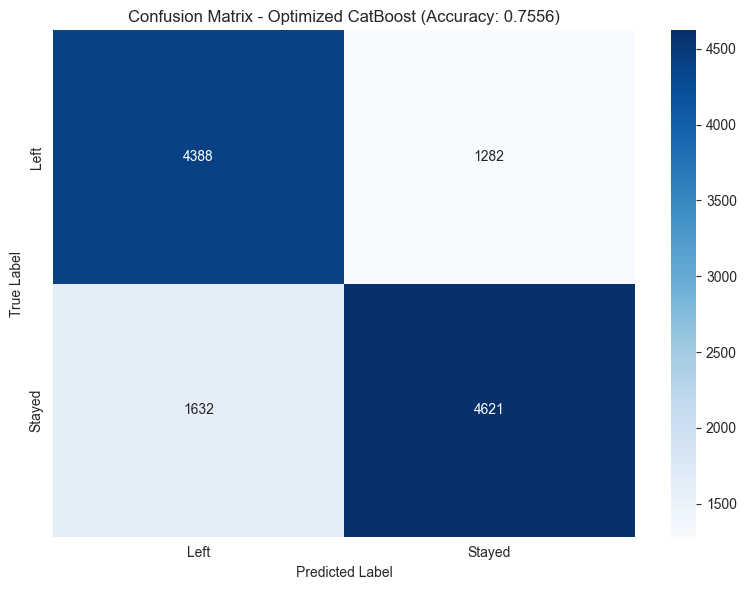

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_val_split, y_val_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Left', 'Stayed'], yticklabels=['Left', 'Stayed'])
plt.title(f'Confusion Matrix - Optimized CatBoost (Accuracy: {val_accuracy:.4f})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

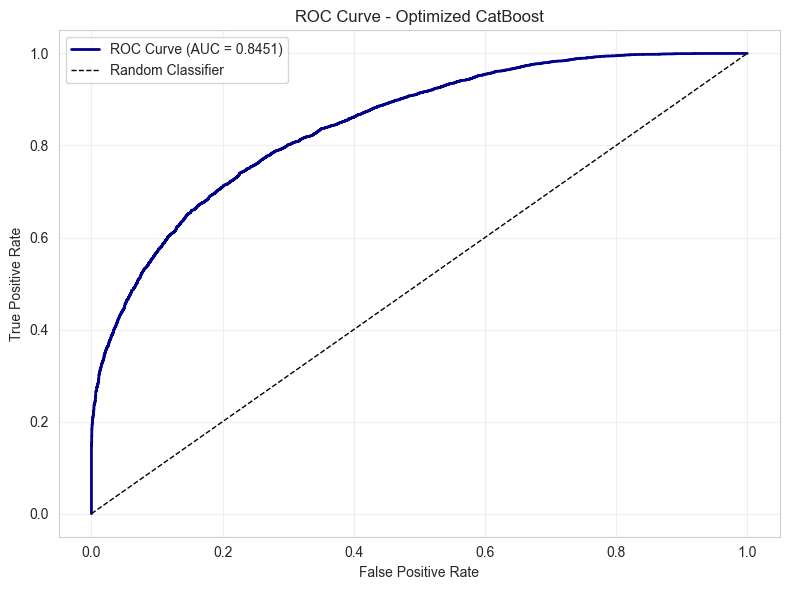

In [11]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_val_split_encoded, y_val_pred_proba[:, 1])
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {val_roc_auc:.4f})', linewidth=2, color='darkblue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Optimized CatBoost')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Visualize optimization history
try:
    fig = plot_optimization_history(study)
    fig.show()
    
    fig = plot_param_importances(study)
    fig.show()
except Exception as e:
    print(f"Could not generate Optuna visualizations: {e}")

Could not generate Optuna visualizations: Mime type rendering requires nbformat>=4.2.0 but it is not installed


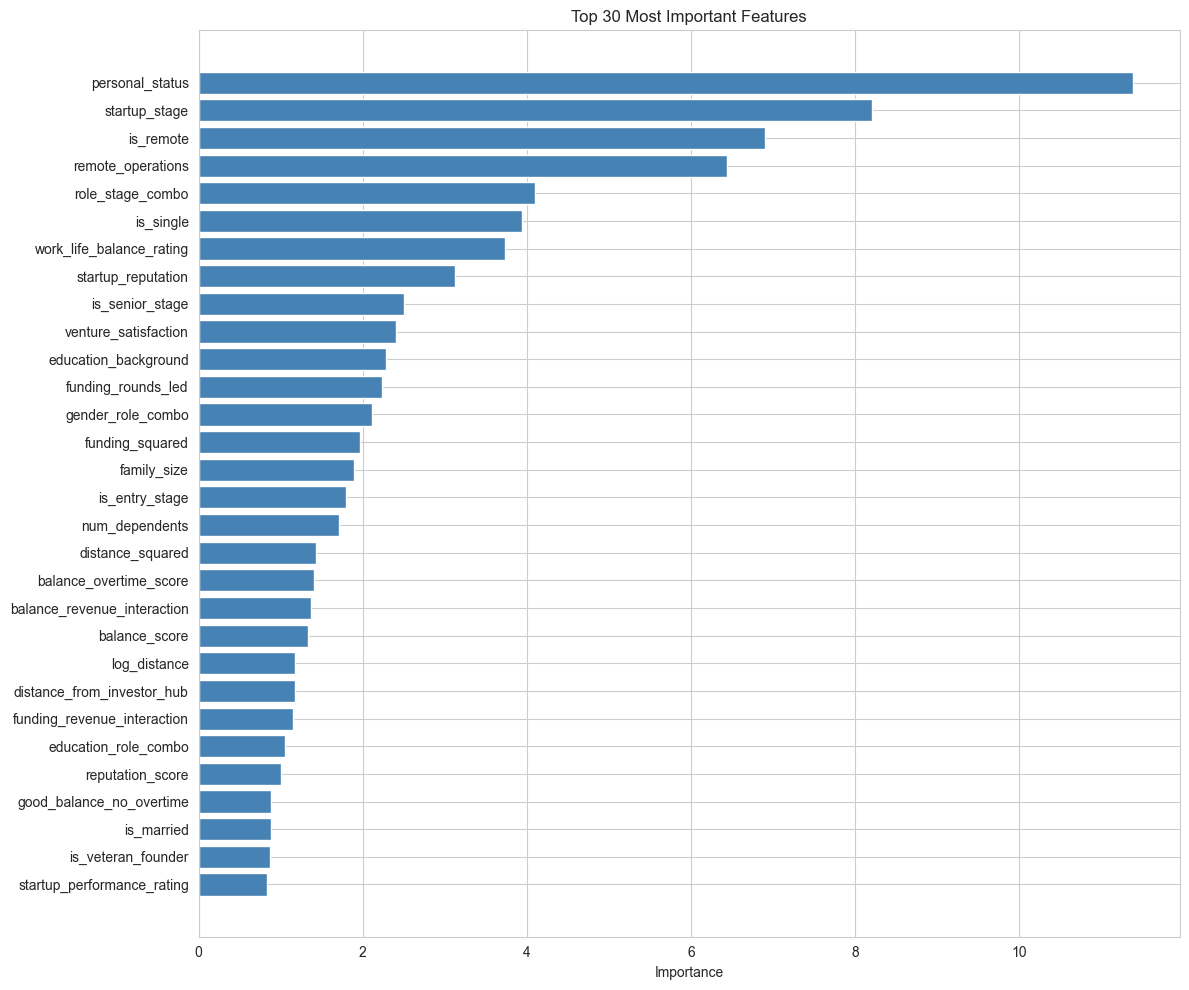


Top 30 Most Important Features:
                    feature  importance
            personal_status   11.387833
              startup_stage    8.206748
                  is_remote    6.897521
          remote_operations    6.437953
           role_stage_combo    4.099280
                  is_single    3.944680
   work_life_balance_rating    3.729386
         startup_reputation    3.124900
            is_senior_stage    2.505124
       venture_satisfaction    2.401953
       education_background    2.284625
         funding_rounds_led    2.237654
          gender_role_combo    2.107887
            funding_squared    1.970391
                family_size    1.893457
             is_entry_stage    1.794787
             num_dependents    1.709414
           distance_squared    1.435841
     balance_overtime_score    1.407515
balance_revenue_interaction    1.374178
              balance_score    1.327201
               log_distance    1.178366
 distance_from_investor_hub    1.171176
funding

In [13]:
# Feature importance analysis
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

# Top 30 features
top_features = feature_importance.head(30)

plt.figure(figsize=(12, 10))
plt.barh(top_features['feature'], top_features['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Top 30 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 30 Most Important Features:")
print(top_features.to_string(index=False))

## 7. Retrain on Full Training Data

In [14]:
# Retrain on full training data for final predictions
print("Retraining model on full training data...\n")
final_model_full = CatBoostClassifier(**best_params)
final_model_full.fit(X_train, y_train, verbose=100)
print("\nModel retrained on full data successfully!")

Retraining model on full training data...

0:	learn: 0.6914248	total: 181ms	remaining: 7m 25s
0:	learn: 0.6914248	total: 181ms	remaining: 7m 25s
100:	learn: 0.5827416	total: 22.6s	remaining: 8m 49s
100:	learn: 0.5827416	total: 22.6s	remaining: 8m 49s
200:	learn: 0.5410198	total: 56s	remaining: 10m 30s
200:	learn: 0.5410198	total: 56s	remaining: 10m 30s
300:	learn: 0.5194352	total: 1m 32s	remaining: 11m 1s
300:	learn: 0.5194352	total: 1m 32s	remaining: 11m 1s
400:	learn: 0.5068480	total: 1m 52s	remaining: 9m 38s
400:	learn: 0.5068480	total: 1m 52s	remaining: 9m 38s
500:	learn: 0.4985377	total: 2m 14s	remaining: 8m 47s
500:	learn: 0.4985377	total: 2m 14s	remaining: 8m 47s
600:	learn: 0.4930967	total: 2m 35s	remaining: 8m 2s
600:	learn: 0.4930967	total: 2m 35s	remaining: 8m 2s
700:	learn: 0.4886552	total: 2m 59s	remaining: 7m 32s
700:	learn: 0.4886552	total: 2m 59s	remaining: 7m 32s
800:	learn: 0.4852018	total: 3m 22s	remaining: 7m
800:	learn: 0.4852018	total: 3m 22s	remaining: 7m
900:	le

## 8. Generate Test Predictions

In [15]:
# Make predictions on test set
y_test_pred = final_model_full.predict(X_test)
y_test_pred_proba = final_model_full.predict_proba(X_test)

print(f"Test predictions generated!")
print(f"\nPrediction distribution:")
print(pd.Series(y_test_pred.flatten()).value_counts())
print(f"\nPrediction proportions:")
print(pd.Series(y_test_pred.flatten()).value_counts(normalize=True))

Test predictions generated!

Prediction distribution:
Left      7455
Stayed    7445
Name: count, dtype: int64

Prediction proportions:
Left      0.500336
Stayed    0.499664
Name: proportion, dtype: float64


## 9. Save Predictions and Model

In [16]:
# Create submission file with probabilities
submission_probs = pd.DataFrame({
    'founder_id': test_ids,
    'retention_status': y_test_pred.flatten(),
    'probability_Left': y_test_pred_proba[:, 0],
    'probability_Stayed': y_test_pred_proba[:, 1]
})

submission_probs.to_csv('catboost_optimized_predictions_with_probs.csv', index=False)
print("Predictions with probabilities saved to 'catboost_optimized_predictions_with_probs.csv'")

# Create standard submission file
submission = pd.DataFrame({
    'founder_id': test_ids,
    'retention_status': y_test_pred.flatten()
})

submission.to_csv('submission_catboost_optimized.csv', index=False)
print("Submission file saved to 'submission_catboost_optimized.csv'")

print("\nFirst 10 predictions:")
print(submission.head(10))

# Save model
final_model_full.save_model('catboost_optimized_model.cbm')
print("\nModel saved to 'catboost_optimized_model.cbm'")

Predictions with probabilities saved to 'catboost_optimized_predictions_with_probs.csv'
Submission file saved to 'submission_catboost_optimized.csv'

First 10 predictions:
   founder_id retention_status
0       52685           Stayed
1       30585             Left
2       54656           Stayed
3       33442             Left
4       15667           Stayed
5        3496           Stayed
6       46775             Left
7       72645             Left
8        4941             Left
9       65181             Left

Model saved to 'catboost_optimized_model.cbm'


## 10. Comprehensive Model Summary

In [19]:
# Save comprehensive model summary
summary = f"""
{'='*70}
OPTIMIZED CATBOOST MODEL SUMMARY
{'='*70}

Dataset Information:
- Training samples: {len(X_train)}
- Validation samples: {len(X_val_split)}
- Test samples: {len(X_test)}
- Total features: {X_train.shape[1]}
- Numeric features: {len(X_train.select_dtypes(include=[np.number]).columns)}
- Categorical features: {len(categorical_features)}

Target Distribution:
- Training Stayed: {(y_train == 'Stayed').sum()} ({(y_train == 'Stayed').sum()/len(y_train)*100:.2f}%)
- Training Left: {(y_train == 'Left').sum()} ({(y_train == 'Left').sum()/len(y_train)*100:.2f}%)

Missing Value Handling:
- monthly_revenue_generated: Median imputation
- num_dependents: Filled with 0 (assume no dependents)
- years_since_founding: Median imputation
- work_life_balance_rating: Filled with 'Fair' (neutral)
- venture_satisfaction: Filled with 'Medium' (neutral)
- team_size_category: Mode imputation

Feature Engineering (85+ features created):
1. Ordinal Encodings (6 features):
   - education_level_encoded, balance_score, satisfaction_score,
   - performance_score, reputation_score, visibility_score

2. Revenue Features (5 features):
   - revenue_per_year, log_revenue, revenue_per_founding_year,
   - is_high_revenue, is_low_revenue

3. Age Features (5 features):
   - age_when_joined, is_young_founder, is_senior_founder,
   - is_prime_age, age_squared

4. Experience Features (5 features):
   - experience_ratio, is_new_founder, is_veteran_founder,
   - tenure_revenue_ratio, years_to_founding_ratio

5. Work-Life Balance Features (4 features):
   - works_overtime, overtime_with_poor_balance,
   - good_balance_no_overtime, balance_overtime_score

6. Performance & Satisfaction Features (5 features):
   - engagement_score, high_performer_satisfied,
   - low_performer_unsatisfied, performance_satisfaction_gap,
   - satisfaction_performance_product

7. Leadership & Funding Features (5 features):
   - has_led_funding, has_multiple_funding,
   - funding_experience_score, avg_funding_per_year, funding_squared

8. Location Features (5 features):
   - near_investor_hub, very_far_from_hub, distance_squared,
   - log_distance, revenue_distance_ratio

9. Family & Personal Features (6 features):
   - has_dependents, has_many_dependents, family_size,
   - is_married, is_single, married_with_dependents

10. Role & Industry Features (4 features):
    - is_tech_role, is_finance_role, tech_finance_role, is_healthcare_role

11. Education & Performance Features (3 features):
    - high_education, education_performance_score, high_edu_high_perf

12. Team & Company Features (6 features):
    - is_large_team, is_small_team, excellent_reputation,
    - poor_reputation, high_visibility, reputation_visibility_product

13. Innovation & Leadership Features (6 features):
    - has_leadership_scope, has_innovation_support, is_remote,
    - innovation_leader, remote_innovator, leadership_no_innovation

14. Stage Features (3 features):
    - is_entry_stage, is_senior_stage, is_mid_stage

15. Gender Features (2 features):
    - is_female, is_male

16. Complex Interaction Features (5 features):
    - age_revenue_interaction, tenure_satisfaction_interaction,
    - education_revenue_interaction, funding_revenue_interaction,
    - balance_revenue_interaction

17. Risk & Loyalty Scores (3 features):
    - risk_score, loyalty_score, is_stable

18. Founding Features (1 feature):
    - founding_maturity_ratio

19. Categorical Combinations (3 features):
    - role_stage_combo, education_role_combo, gender_role_combo

Best Hyperparameters:
{chr(10).join(f'- {k}: {v}' for k, v in best_params.items() if k not in ['cat_features', 'verbose'])}

Validation Performance:
- Accuracy: {val_accuracy:.6f}
- ROC AUC: {val_roc_auc:.6f}
- Best Iteration: {final_model.best_iteration_}

Optimization Details:
- Number of trials: 50
- Cross-validation folds: 5
- Best CV score: {study.best_value:.6f}

Top 10 Most Important Features:


Output Files:
- catboost_optimized_predictions_with_probs.csv
- submission_catboost_optimized.csv
- catboost_optimized_model.cbm
- catboost_optimized_summary.txt

{'='*70}
"""

print(summary)

with open('catboost_optimized_summary.txt', 'w') as f:
    f.write(summary)

print("Model summary saved to 'catboost_optimized_summary.txt'")


OPTIMIZED CATBOOST MODEL SUMMARY

Dataset Information:
- Training samples: 59611
- Validation samples: 11923
- Test samples: 14900
- Total features: 104
- Numeric features: 86
- Categorical features: 18

Target Distribution:
- Training Stayed: 31265 (52.45%)
- Training Left: 28346 (47.55%)

Missing Value Handling:
- monthly_revenue_generated: Median imputation
- num_dependents: Filled with 0 (assume no dependents)
- years_since_founding: Median imputation
- work_life_balance_rating: Filled with 'Fair' (neutral)
- venture_satisfaction: Filled with 'Medium' (neutral)
- team_size_category: Mode imputation

Feature Engineering (85+ features created):
1. Ordinal Encodings (6 features):
   - education_level_encoded, balance_score, satisfaction_score,
   - performance_score, reputation_score, visibility_score

2. Revenue Features (5 features):
   - revenue_per_year, log_revenue, revenue_per_founding_year,
   - is_high_revenue, is_low_revenue

3. Age Features (5 features):
   - age_when_joine

In [20]:
# Final message
print("\n" + "="*70)
print("TRAINING COMPLETE!")
print("="*70)
print(f"\nValidation Accuracy: {val_accuracy:.6f}")
print(f"ROC AUC Score: {val_roc_auc:.6f}")
print(f"\nAll files saved successfully!")
print("\nReady for submission: submission_catboost_optimized.csv")


TRAINING COMPLETE!

Validation Accuracy: 0.755598
ROC AUC Score: 0.845067

All files saved successfully!

Ready for submission: submission_catboost_optimized.csv
